In [143]:
import os, re, unicodedata, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings("ignore")

In [144]:
cd C:\Users\tr432\Downloads

C:\Users\tr432\Downloads


In [145]:
# ===============================
# USER INPUT (Edit)
# ===============================
FILES = {
    "0w": "filter_GutLungAxis_Week0/rel_gg2_genus_table.tsv",
    "1w": "filter_GutLungAxis_Week1/rel_gg2_genus_table.tsv",
    "2w": "filter_GutLungAxis_Week2/rel_gg2_genus_table.tsv",
}
#tax = "d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Phocaeicola_A"
#tax = "d__Bacteria;p__Actinomycetota;c__Actinomycetes;o__Actinomycetales;f__Bifidobacteriaceae;g__Bifidobacterium_388775"
#tax = "d__Bacteria;p__Bacillota_I;c__Bacilli_A;o__Lactobacillales;f__Lactobacillaceae;g__Lactobacillus"
#tax = "d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales_737866;f__Enterobacteriaceae_A_725029;g__Escherichia"  # Edit: '#OTU ID' 열에서 "정확히 일치"하는 문자열
tax = "d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales_737866;f__Enterobacteriaceae_A_732334;g__Proteus"  # Edit: '#OTU ID' 열에서 "정확히 일치"하는 문자열

# q-value는 직접 입력 (각 week별)
QVAL = {
#    "0w": 0.963711378969258,     # Edit: Phocaeicola_A
#    "0w": 0.963711378969258,     #Edit: Bifidobacterium_388775
#    "0w": 0.96961122433241,      #Edit: Lactobacillus
#    "0w": "N/A",                 #Edit: Escherichia
    "0w": "N/A",                 #Edit: Proteus

#    "1w": 0.0111833445205693,     #Edit: Phocaeicola_A
#    "1w": 0.00240518118242556,   #Edit: Bifidobacterium_388775
#    "1w": 1,                     #Edit: Lactobacillus
#    "1w": 0.00762574584993256,   # Edit: Escherichia
    "1w": 0.777909159654521,   # Edit: Proteus

#    "2w": 0.0102722124981232     #Edit: Phocaeicola_A
#    "2w": 0.0102722124981232     #Edit: Bifidobacterium_388775
#    "2w": 0.0414672024527658     #Edit: Lactobacillus
#    "2w": 0.0438515383812155     #Edit: Escherichia
    "2w": "N/A"                  # Edit: Proteus
}

# (선택) y축 log10 변환이 필요하면 True (상대풍부도면 보통 False 권장)
APPLY_LOG10 = False
PSEUDO = 1  # log10용

# 그룹 판별 규칙(필요시 수정)
def infer_group(sample_name: str) -> str | None:
    s = str(sample_name).strip()
    if s.startswith("C"): return "Control"
    if s.startswith("V"): return "VNAM"
    return None

WEEKS = ["0w", "1w", "2w"]
GROUP_ORDER = ["Control", "VNAM"]

In [146]:
# ===============================
# Helpers
# ===============================
def q_to_stars(q):
    # q가 문자열("N/A" 등)이면 ns로 간주
    try:
        qf = float(q)
    except (TypeError, ValueError):
        return "ns"
    if np.isnan(qf):
        return "ns"
    if qf < 0.001: return "***"
    if qf < 0.01:  return "**"
    if qf < 0.05:  return "*"
    return "ns"

def format_q(q):
    # 표기용: 숫자면 scientific, 아니면 문자열 그대로
    try:
        qf = float(q)
        if np.isnan(qf):
            return "N/A"
        return f"{qf:.2e}"
    except (TypeError, ValueError):
        return str(q)


def add_bracket(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y+0.5*h, y+0.5*h, y], lw=1, c="k")
    ax.text((x1+x2)/2, y+0.5*h, text, ha="center", va="bottom", fontsize=22, fontweight='bold')

def infer_subject_id(sample_name: str, wk: str) -> str:
    s = str(sample_name).strip()
    # 예: C01_0w / C01-0w / C01.0w 같은 suffix 제거
    s = re.sub(rf'([_\-\.]?)\b{re.escape(wk)}\b$', "", s)
    s = re.sub(r'[_\-\.\s]+$', "", s)
    return s

In [147]:
# ===============================
# 1) Load -> long format
# ===============================
rows = []
for wk in WEEKS:
    dfw = pd.read_csv(FILES[wk], sep="\t", skiprows=1)
    if "#OTU ID" not in dfw.columns:
        raise ValueError(f"[{wk}] '#OTU ID' 컬럼이 없습니다. 현재 컬럼: {list(dfw.columns)[:10]} ...")

    # ✅ exact match only
    hit = dfw[dfw["#OTU ID"].astype(str).str.strip() == str(tax).strip()]
    if hit.shape[0] != 1:
        if hit.shape[0] == 0:
            # 보조(대소문자만 다른 경우 1개면 허용)
            hit2 = dfw[dfw["#OTU ID"].astype(str).str.strip().str.casefold()
                      == str(tax).strip().casefold()]
            if hit2.shape[0] == 1:
                hit = hit2
            else:
                raise ValueError(f"[{wk}] tax='{tax}' 정확히 일치하는 행이 없습니다. (현재 파일: {FILES[wk]})")
        else:
            raise ValueError(f"[{wk}] tax='{tax}' 정확히 일치하는 행이 {hit.shape[0]}개입니다. 유일해야 합니다.")

    row = hit.iloc[0]

    # sample columns = '#OTU ID' 제외한 나머지
    for col in dfw.columns:
        if col == "#OTU ID":
            continue
        g = infer_group(col)
        if g is None:
            continue
        val = pd.to_numeric(row[col], errors="coerce")
        if pd.isna(val):
            continue
        subj = infer_subject_id(col, wk)
        rows.append({"Week": wk, "Group": g, "Sample": col, "Subject": subj, "Value": float(val)})

dat = pd.DataFrame(rows)
if dat.empty:
    raise ValueError("선택된 tax에 대해 유효한 값이 없습니다(모두 NA/비어있음).")

dat["Value"] = dat["Value"].astype(float) * 100

if APPLY_LOG10:
    dat["Value"] = np.log10(dat["Value"].to_numpy(dtype=float) + PSEUDO)
    YLABEL = "Log10 (Value)"
else:
    YLABEL = "Value"

dat["Group6"] = dat["Week"].astype(str) + "_" + dat["Group"].astype(str)

In [148]:
# dat 컬럼 필요: ["sample_id"(또는 #SampleID), "Group", "Week", "Value"]
# Week 값 예: "0w","1w","2w" / Group 값 예: "Control","VNAM"

# 0) SubjectID(개체ID) 만들기: C01-0w -> C01, V01-2w -> V01
SID_COL = "Subject"  # 실제 컬럼명에 맞게 바꾸세요(#SampleID 등)
dat = dat.copy()
dat["SubjectID"] = dat[SID_COL].astype(str).str.replace(r"-\d+w$", "", regex=True)

WEEKS = ["0w","1w","2w"]
GROUP_ORDER = ["Control","VNAM"]

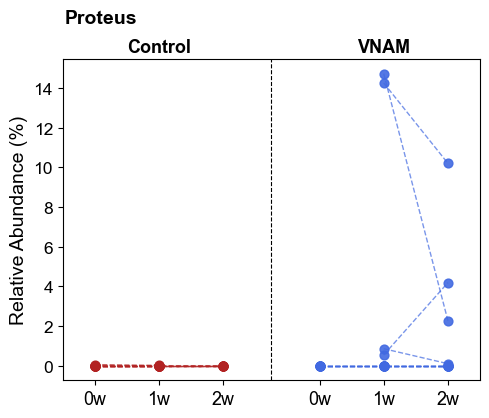

In [149]:
# 1) x 위치: Control칸(0,1,2) + VNAM칸(4,5,6) 처럼 간격을 둠
gap = 0.5
x_control = {wk: i for i, wk in enumerate(WEEKS)}
x_vnam    = {wk: i + len(WEEKS) + gap for i, wk in enumerate(WEEKS)}
x_map = {"Control": x_control, "VNAM": x_vnam}

vline_x = len(WEEKS) - 0.5 + gap/2  # 두 칸 경계선

fig, ax = plt.subplots(figsize=(5, 4))

# 2) 점 + (선택) 요약치(bar/mean 등)은 원하면 추가
#    여기서는 점 + 개체별 점선만 예시
rng = np.random.default_rng(0)

COL_MAP = {"Control": "firebrick",
           "VNAM": "royalblue"}

for g in GROUP_ORDER:
    subg = dat[dat["Group"] == g].copy()
    if subg.empty:
        continue

    # week 순서 정렬
    subg["Week"] = pd.Categorical(subg["Week"], categories=WEEKS, ordered=True)
    subg = subg.sort_values(["SubjectID","Week"])

    # (A) 개별 점 찍기 (jitter는 x만)
    for wk in WEEKS:
        tmp = subg[subg["Week"] == wk]
        if tmp.empty: 
            continue
        x0 = x_map[g][wk]
#        jit = rng.uniform(-0.08, 0.08, size=len(tmp))
        ax.scatter(
#            x0 + jit,
            np.full(len(tmp), x0),          # ← jitter 없음
            tmp["Value"].to_numpy(float),
            s=40, alpha=0.9, color=COL_MAP[g], zorder=3
        )

    # (B) 같은 SubjectID를 0w-1w-2w로 점선 연결
    for sid, dsi in subg.groupby("SubjectID"):
        dsi = dsi.dropna(subset=["Value","Week"])
        if dsi.shape[0] < 2:
            continue
        xs = [x_map[g][wk] for wk in dsi["Week"].astype(str)]
        ys = dsi["Value"].to_numpy(float)
        ax.plot(xs, ys, ls="--", lw=1.0, alpha=0.7, color=COL_MAP[g], zorder=2)

# 3) 축/레이블/칸 제목
ax.axvline(vline_x, ls="--", lw=0.8, c="black", zorder=0)

xticks = [x_control[w] for w in WEEKS] + [x_vnam[w] for w in WEEKS]
xlabels = WEEKS + WEEKS
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels, fontsize=13)

# 칸 제목(위쪽)
trans = ax.get_xaxis_transform()
ax.text(np.mean(list(x_control.values())), 1.01, "Control", transform=trans,
        ha="center", va="bottom", fontsize=13, fontweight="bold")
ax.text(np.mean(list(x_vnam.values())), 1.01, "VNAM", transform=trans,
        ha="center", va="bottom", fontsize=13, fontweight="bold")

plt.xlabel('')
plt.ylabel('Relative Abundance (%)', fontsize=14)
plt.xlim(-0.5, max(x_vnam.values()) + 0.5)
plt.yticks(fontsize=12.5)

fig.text(0.14, 1.035, 'Proteus', ha="left", va="top", fontsize=14, fontweight="bold")  #Edit

plt.tight_layout()
plt.savefig("trend_Proteus.png", dpi=500, bbox_inches="tight")
plt.show()

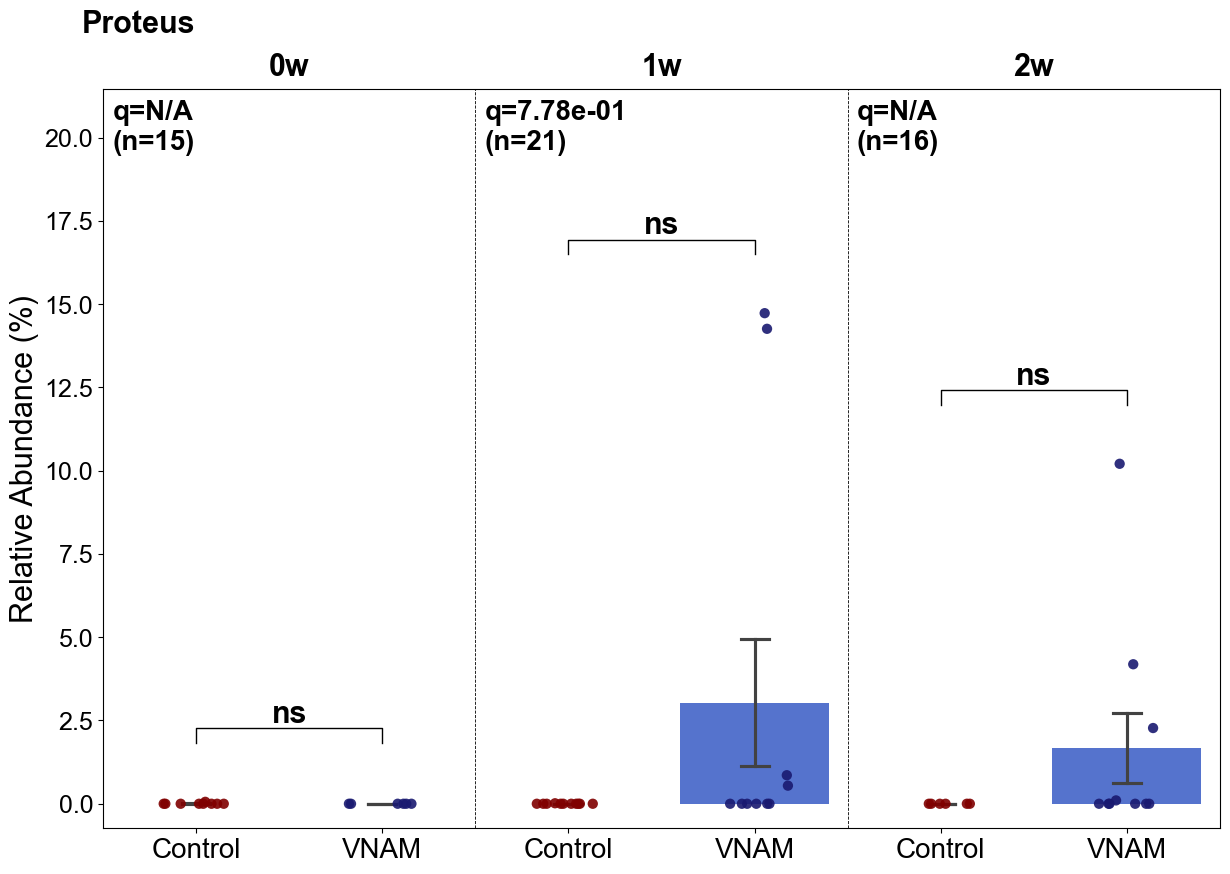

In [150]:
# ===============================
# 2) Plot (single axis, 3 panels separated by vlines)  -- BAR VERSION
# ===============================
COLOR = ["maroon", "midnightblue"] * len(WEEKS)

order = []
for wk in WEEKS:
    order += [f"{wk}_{GROUP_ORDER[0]}", f"{wk}_{GROUP_ORDER[1]}"]

centers = {wk: i*2 + 0.5 for i, wk in enumerate(WEEKS)}
vlines  = [1.5 + 2*i for i in range(len(WEEKS)-1)]

# scatter용 x/색 매핑 (scatter를 남길 경우에만 사용)
x_map = {cat: i for i, cat in enumerate(order)}
c_map = {cat: COLOR[i] for i, cat in enumerate(order)}
rng   = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=(12.4, 8.4))

# ✅ 1) BARPLOT (mean + errorbar)
# seaborn>=0.12: errorbar="se" 가능 / 에러바 싫으면 errorbar=None
sns.barplot(
    data=dat, x="Group6", y="Value", order=order,
    estimator=np.mean,
    errorbar="se",          # 또는 None
    palette=["firebrick", "royalblue"] * len(WEEKS),     # ["firebrick","royalblue"] * len(WEEKS) 그대로 사용 가능
    ax=ax,
    capsize=0.15
)

# ✅ (선택) 2) scatter overlay (jitter) - 개별 샘플 점도 같이 보고 싶으면 유지
base_x = dat["Group6"].map(x_map).to_numpy(dtype=float)
jitter = rng.uniform(-0.18, 0.18, size=len(dat))
xj     = base_x + jitter
colors = dat["Group6"].map(c_map).to_list()

ax.scatter(
    xj, dat["Value"].to_numpy(dtype=float),
    s=55, alpha=0.9, c=colors, zorder=3, linewidths=0
)

# week separator vlines
for xv in vlines:
    ax.axvline(xv, ls="--", lw=0.6, c="black", zorder=0)

# x tick labels: Control/VNAM repeat
ax.set_xticks(np.arange(len(order)))
ax.set_xticklabels(GROUP_ORDER * len(WEEKS), rotation=0)

# week titles
trans = ax.get_xaxis_transform()
for wk in WEEKS:
    ax.text(
        centers[wk], 1.01, wk, transform=trans,
        ha="center", va="bottom", fontsize=22, fontweight="bold", clip_on=False
    )

# brackets + stars + q text (q는 직접 입력)
y_min, y_max = np.nanmin(dat["Value"]), np.nanmax(dat["Value"])
yrng = (y_max - y_min) if np.isfinite(y_max - y_min) and (y_max - y_min) > 0 else 1.0
h = yrng * 0.06
y_bracket_max = y_max

for i, wk in enumerate(WEEKS):
    subw = dat[dat["Week"] == wk]
    if subw.empty:
        continue

    q_raw = QVAL.get(wk, np.nan)
    n = int(subw.shape[0])

    ymax_w = np.nanmax(subw["Value"])   # bar만 쓸 거면 mean 기반으로 바꿔도 됨
    y = ymax_w + h*2
    x1, x2 = i*2, i*2 + 1

    add_bracket(ax, x1, x2, y, h, q_to_stars(q_raw))
    y_bracket_max = max(y_bracket_max, y + 0.6*h)

    ax.text(x1-0.45, 0.91, f"q={format_q(q_raw)}\n(n={n})",
            transform=trans, ha="left", va="bottom", fontsize=20, fontweight='bold', clip_on=False)

# y-limits padding
pad_bottom = yrng * 0.05
pad_top    = yrng * 0.3
plt.ylim(y_min - pad_bottom, y_bracket_max + pad_top)

plt.xlim(-0.5, len(order)-0.5)
plt.xlabel('')
plt.xticks(fontsize=20)
plt.yticks(fontsize=18)
plt.ylabel("Relative Abundance (%)", fontsize=22)

fig.text(0.07, 1.035, "Proteus", ha="left", va="top", fontsize=22, fontweight="bold")  #Edit

plt.tight_layout()
plt.savefig("bar_Proteus.png", dpi=500, bbox_inches="tight")
plt.show()

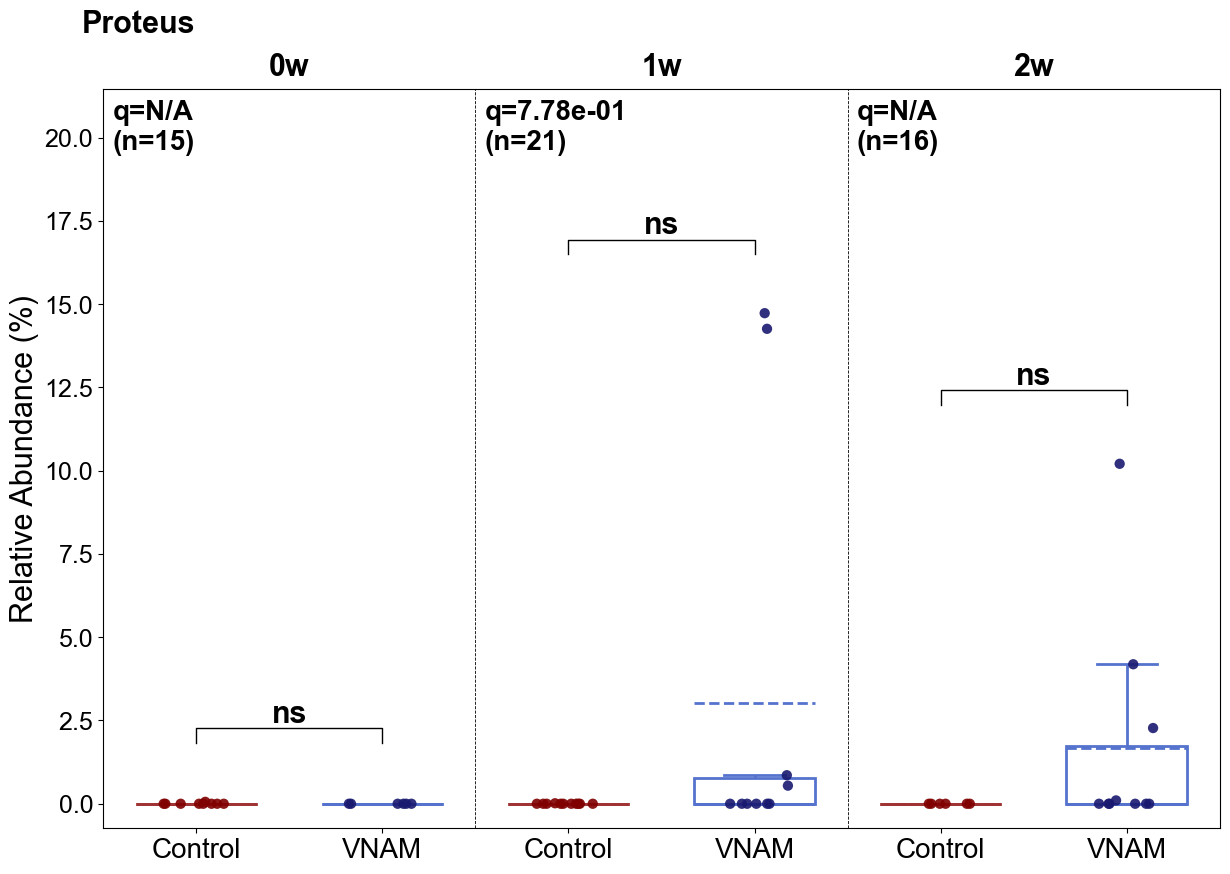

In [151]:
# ===============================
# 2) Plot (single axis, 3 panels separated by vlines)
# ===============================
COLOR = ["maroon", "midnightblue"] * len(WEEKS)

order = []
for wk in WEEKS:
    order += [f"{wk}_{GROUP_ORDER[0]}", f"{wk}_{GROUP_ORDER[1]}"]

centers = {wk: i*2 + 0.5 for i, wk in enumerate(WEEKS)}
vlines  = [1.5 + 2*i for i in range(len(WEEKS)-1)]

# scatter mapping
x_map = {cat: i for i, cat in enumerate(order)}
c_map = {cat: COLOR[i] for i, cat in enumerate(order)}
rng   = np.random.default_rng(0)

# ✅ [ADD HERE] log10 transform (0 방지 pseudocount)
#PSEUDO = 1.0   # reads면 1.0 권장, 상대풍부도면 1e-6 ~ 1e-4
#dat["Value"] = np.log10(dat["Value"].astype(float) + PSEUDO)
#YLABEL = "Log10 (Reads)"

fig, ax = plt.subplots(figsize=(12.4, 8.4))

# 1) boxplot
sns.boxplot(
    data=dat, x="Group6", y="Value", order=order,
    showmeans=True, meanline=True, meanprops={'color': 'k', 'lw': 1},
    palette=["firebrick", "royalblue"] * len(WEEKS), width=0.65, fliersize=0, ax=ax
)

# 2) outline-only boxes (transparent fill + colored edges)
box_patches = [p for p in ax.patches if isinstance(p, mpatches.PathPatch)]
box_patches = box_patches[:len(order)]

lines = ax.lines
nbox  = len(box_patches)
k     = (len(lines) // nbox) if nbox else 0

for i, p in enumerate(box_patches):
    fc = p.get_facecolor()
    p.set_facecolor((0, 0, 0, 0))
    p.set_edgecolor(fc)
    p.set_linewidth(2)
    if k:
        for ln in lines[i*k:(i+1)*k]:
            ln.set_color(fc)
            ln.set_linewidth(2)

# 3) scatter overlay (jitter)
base_x = dat["Group6"].map(x_map).to_numpy(dtype=float)
jitter = rng.uniform(-0.18, 0.18, size=len(dat))
xj     = base_x + jitter
colors = dat["Group6"].map(c_map).to_list()

ax.scatter(
    xj, dat["Value"].to_numpy(dtype=float),
    s=55, alpha=0.9, c=colors, zorder=3, linewidths=0
)

# week separator vlines
for xv in vlines:
    ax.axvline(xv, ls="--", lw=0.6, c="black", zorder=0)

# x tick labels: Control/VNAM repeat
ax.set_xticks(np.arange(len(order)))
ax.set_xticklabels(GROUP_ORDER * len(WEEKS), rotation=0)

# week titles
trans = ax.get_xaxis_transform()
for wk in WEEKS:
    ax.text(
        centers[wk], 1.01, wk, transform=trans,
        ha="center", va="bottom", fontsize=22, fontweight="bold", clip_on=False
    )

# brackets + stars + q text (q는 직접 입력)
y_min, y_max = np.nanmin(dat["Value"]), np.nanmax(dat["Value"])
yrng = (y_max - y_min) if np.isfinite(y_max - y_min) and (y_max - y_min) > 0 else 1.0
h = yrng * 0.06
y_bracket_max = y_max

for i, wk in enumerate(WEEKS):
    subw = dat[dat["Week"] == wk]
    if subw.empty:
        continue

    q_raw = QVAL.get(wk, np.nan)  # 숫자/문자열 모두 허용
    n = int(subw.shape[0])  # week 전체 샘플수(=Control+VNAM)

    ymax_w = np.nanmax(subw["Value"])
    y = ymax_w + h*2
    x1, x2 = i*2, i*2 + 1

    add_bracket(ax, x1, x2, y, h, q_to_stars(q_raw))
    y_bracket_max = max(y_bracket_max, y + 0.6*h)

    ax.text(x1-0.45, 0.91, f"q={format_q(q_raw)}\n(n={n})",
        transform=trans, ha="left", va="bottom", fontsize=20, fontweight='bold', clip_on=False)

# y-limits padding
pad_bottom = yrng * 0.05
pad_top    = yrng * 0.3
plt.ylim(y_min - pad_bottom, y_bracket_max + pad_top)

plt.xlim(-0.5, len(order)-0.5)
plt.xlabel('')
plt.xticks(fontsize=20)
plt.yticks(fontsize=18)
plt.ylabel('Relative Abundance (%)', fontsize=22)

# figure-level title (left)
#fig.text(0.055, 1.02, str(tax), ha="left", va="top", fontsize=20, fontweight="bold")  ## 처음에 설정한 균주명 그대로 쓸때 사용 (rel_genus_table.tsv 에 있는 이름이어야 함)
fig.text(0.07, 1.035, 'Proteus', ha="left", va="top", fontsize=22, fontweight="bold")  #Edit

plt.tight_layout()
plt.savefig("box_Proteus.png", dpi=500, bbox_inches="tight")
plt.show()

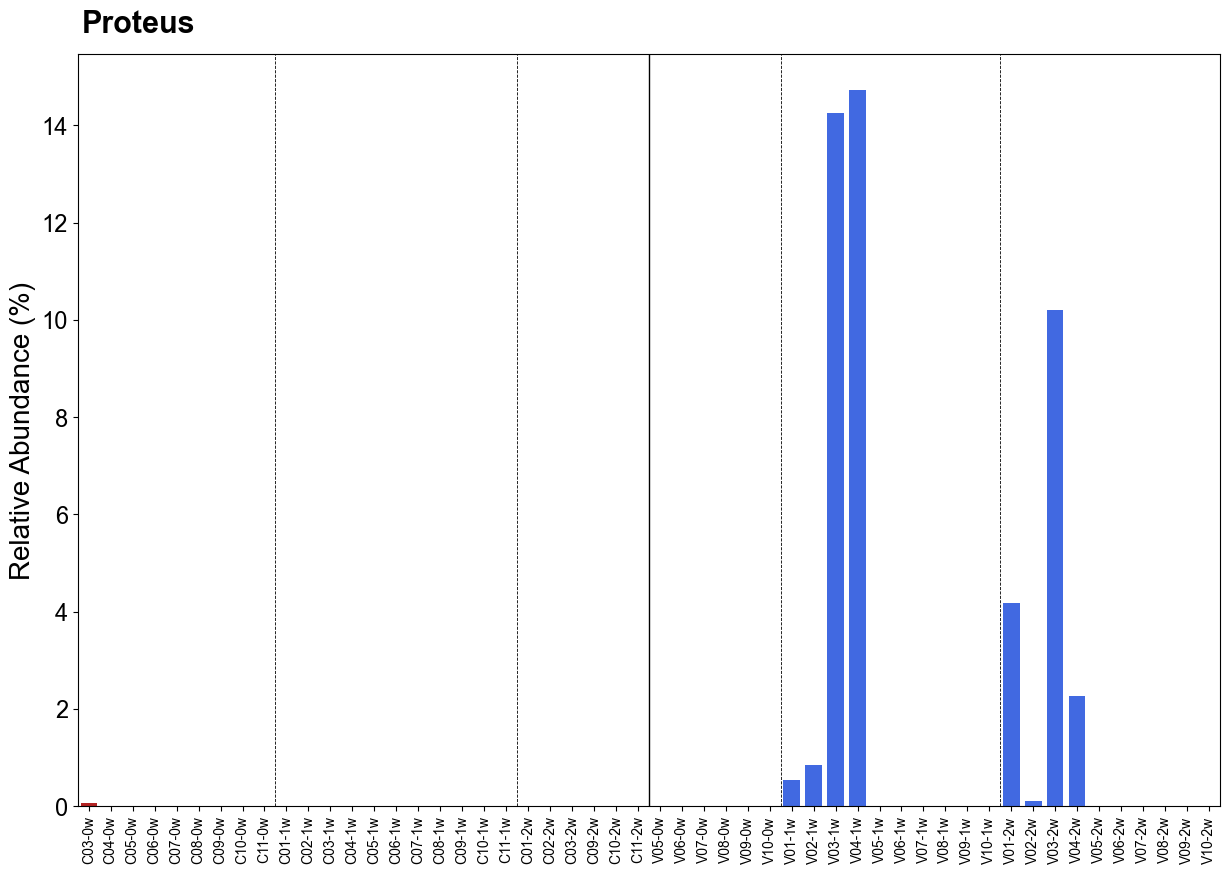

In [152]:
# ===============================
# BAR (each sample) + LINE (sequential) with x-axis = Sample name
# ===============================
COL = {"Control": "firebrick", "VNAM": "royalblue"}

# dat에 Sample 컬럼이 있어야 함 (rows.append에 "Sample": col 넣었을 때 생성됨)
if "Sample" not in dat.columns:
    raise ValueError("dat에 'Sample' 컬럼이 없습니다. rows.append에 Sample을 추가해서 dat를 다시 만드세요.")

# Week/Group 순서 고정
dat2 = dat.copy()
# ✅ [ADD HERE] log10 transform (0 방지 pseudocount)
#PSEUDO = 1.0
#dat2["Value"] = np.log10(dat2["Value"].astype(float) + PSEUDO)
#YLABEL = "Log10 (Reads)"
#dat2["Week"]  = pd.Categorical(dat2["Week"],  categories=WEEKS, ordered=True)
#dat2["Group"] = pd.Categorical(dat2["Group"], categories=GROUP_ORDER, ordered=True)

# ✅ 그려지는 '순서' = Week -> Group -> (파일 컬럼 순서대로 들어온 Sample)
# Sample 정렬을 바꾸고 싶으면 아래 sort_values에 "Sample" 추가/제거하면 됨
#dat2 = dat2.sort_values(["Week", "Group"], kind="mergesort").reset_index(drop=True)
dat2 = dat2.sort_values(["Group", "Week"], kind="mergesort").reset_index(drop=True)

x = np.arange(len(dat2))

fig, ax = plt.subplots(figsize=(12.4, 8.4))

# bar: 각 샘플 1개씩
for i, r in dat2.iterrows():
    grp = str(r["Group"])
    ax.bar(
        x[i], float(r["Value"]), width=0.75,
        color=COL.get(grp, "gray"), edgecolor=COL.get(grp, "gray"),
        linewidth=0, zorder=2
    )

# line: 그룹별로 "순서대로" 전부 이어줌 (같은 것끼리 매칭 없음)
#for grp in GROUP_ORDER:
#    idx = dat2.index[dat2["Group"].astype(str) == grp].to_numpy()
#    if len(idx) >= 2:
#        ax.plot(x[idx], dat2.loc[idx, "Value"].to_numpy(float),
#                lw=1.2, alpha=0.7, color=COL[grp], zorder=3)

# (선택) Week 경계선
#week_change = np.where(dat2["Week"].astype(str).values[:-1] != dat2["Week"].astype(str).values[1:])[0]
#for k in week_change:
#    ax.axvline(k + 0.5, ls="--", lw=0.6, c="black", zorder=0)
block = (dat2["Group"].astype(str) + "_" + dat2["Week"].astype(str)).values
block_change = np.where(block[:-1] != block[1:])[0]
#for k in block_change:
#    ax.axvline(k + 0.5, ls="--", lw=0.6, c="black", zorder=0)

# (선택) block 경계선: Group 바뀌는 곳은 실선, Week만 바뀌는 곳은 점선
grp = dat2["Group"].astype(str).values
wk  = dat2["Week"].astype(str).values

for k in range(len(dat2) - 1):
    grp_change = (grp[k] != grp[k+1])
    wk_change  = (wk[k]  != wk[k+1])

    if grp_change or wk_change:
        ax.axvline(
            k + 0.5,
            ls="-" if grp_change else "--",   # ✅ Group 경계=실선, Week 경계=점선
            lw=1 if grp_change else 0.6,    # ✅ Group 경계 더 굵게
            c="black",
            zorder=0
        )

# x축 = 샘플명
ax.set_xticks(x)
ax.set_xticklabels(dat2["Sample"].astype(str).tolist(), rotation=90, ha="center")
plt.xticks(fontsize=10)
plt.yticks(fontsize=17)

plt.xlabel('')
plt.ylabel('Relative Abundance (%)', fontsize=20)

# 제목
fig.text(0.07, 1.035, 'Proteus', ha="left", va="top",
         fontsize=22, fontweight="bold")  #Edit

plt.xlim(-0.5, len(x)-0.5)
plt.ylim(-0.0,)

plt.tight_layout()
plt.savefig("ind_Proteus.png", dpi=500, bbox_inches="tight")
plt.show()